<a href="https://colab.research.google.com/github/naqirraza99/CS-351L---AI-Lab1_2022574/blob/main/Lab3/NaqiRaza_CS351L_Lab03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

image.png

**Choose a Real-World Scenario**

In this task, the scenario of map coloring is selected, where neighboring countries need to be colored such that no two adjacent countries share the same color. This scenario models a Constraint Satisfaction Problem (CSP), where the constraints are that adjacent countries (i.e., countries sharing a border) must have different colors.

This choice is highly applicable to graph coloring because:

Each country can be represented as a node.
Borders between countries can be represented as edges.
The goal is to assign colors (like Red, Green, Blue) to countries such that no two neighboring countries have the same color.

**Modify the Code**


**Adaptation:** The code is modified to represent countries as nodes and borders as edges. Instead of generic graph nodes, the countries and their neighboring relations are mapped directly from the scenario.

A dictionary is used to represent neighboring countries as a graph.
The backtracking graph coloring algorithm is modified to apply colors to these countries while avoiding conflicts.

**Nodes and Edges:** The countries are represented by nodes, and the borders between them are represented by edges. For instance, countries like Pakistan, India, Afghanistan, and China are treated as nodes, and borders between them are treated as edges in the graph. The real-world data of borders between countries has been added.

**Visualization Changes:** Visualization is enhanced to display the names of the countries (instead of generic numbers) and shows step-by-step coloring of the graph, making the map coloring process more intuitive. The countries are visualized in color, and uncolored nodes are shown in white during intermediate steps.

**Visualize Each Step**

**Graph Coloring Process Visualization:**

*   At each step, the current state of the graph (countries with their assigned colors) is displayed. This includes showing the nodes (countries) and their current color assignments, along with uncolored nodes.
* The graph is displayed after each coloring decision using the Minimum Remaining Values (MRV) heuristic, which selects the country with the fewest available legal colors first.

**Clarity of Visualization:** The matplotlib and networkx libraries are used to visualize the graph. Node colors are dynamically updated as the algorithm progresses, showing each country being colored step by step.

**Neighboring Countries with MRV Heuristic**

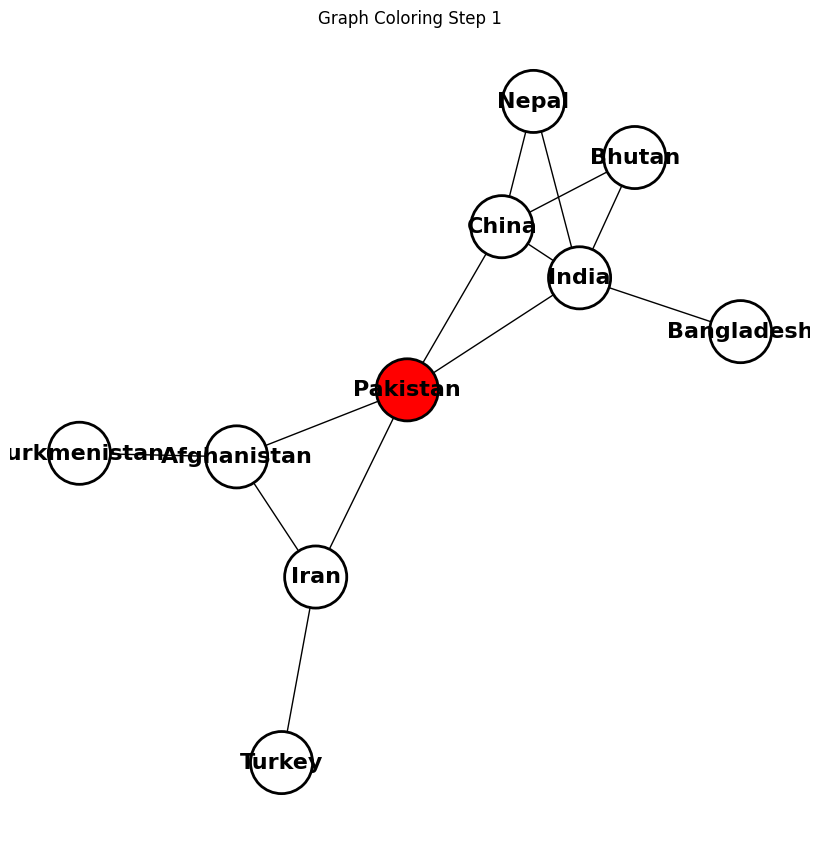

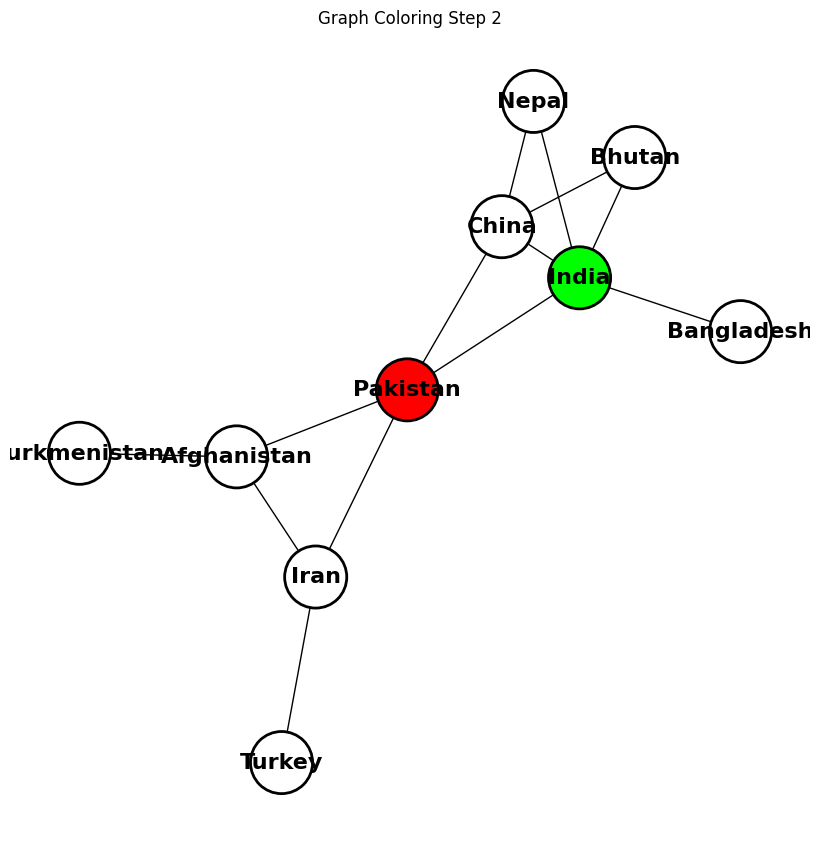

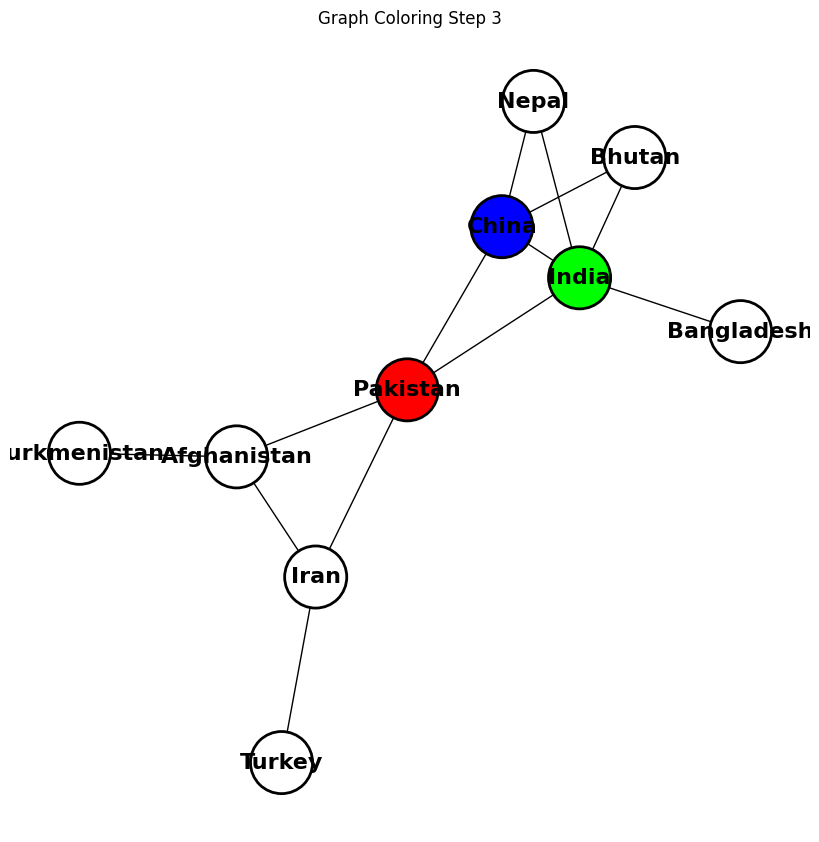

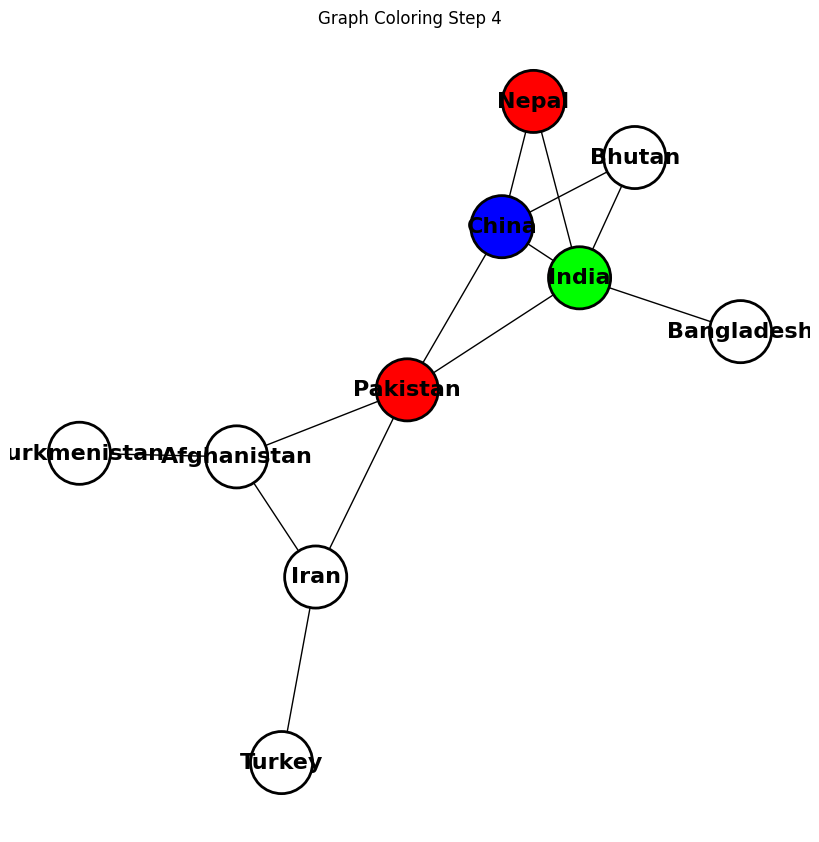

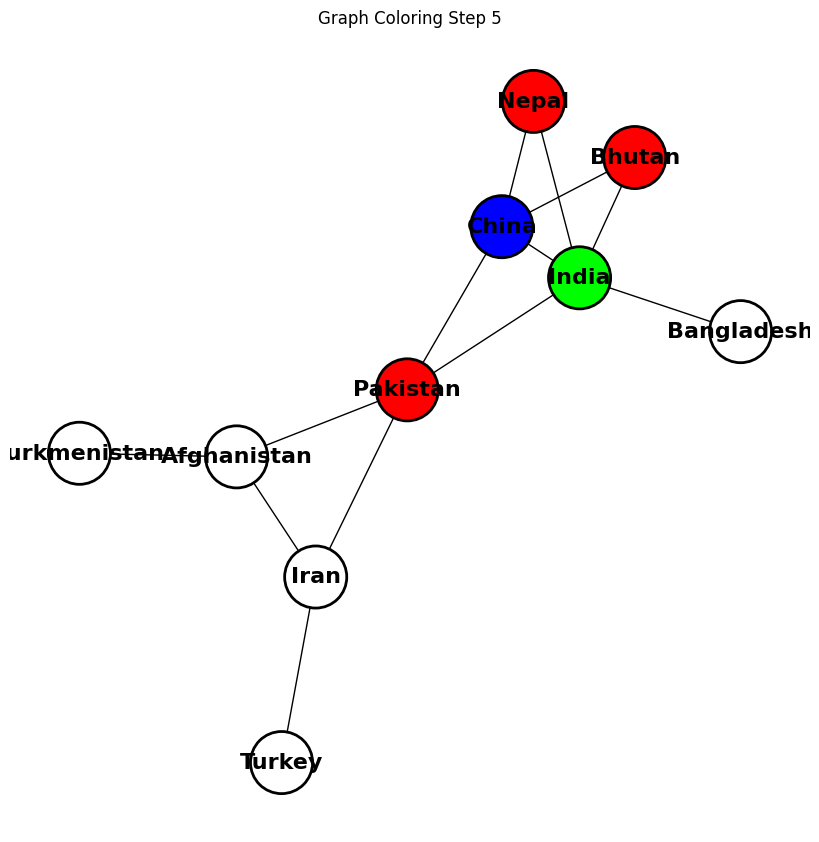

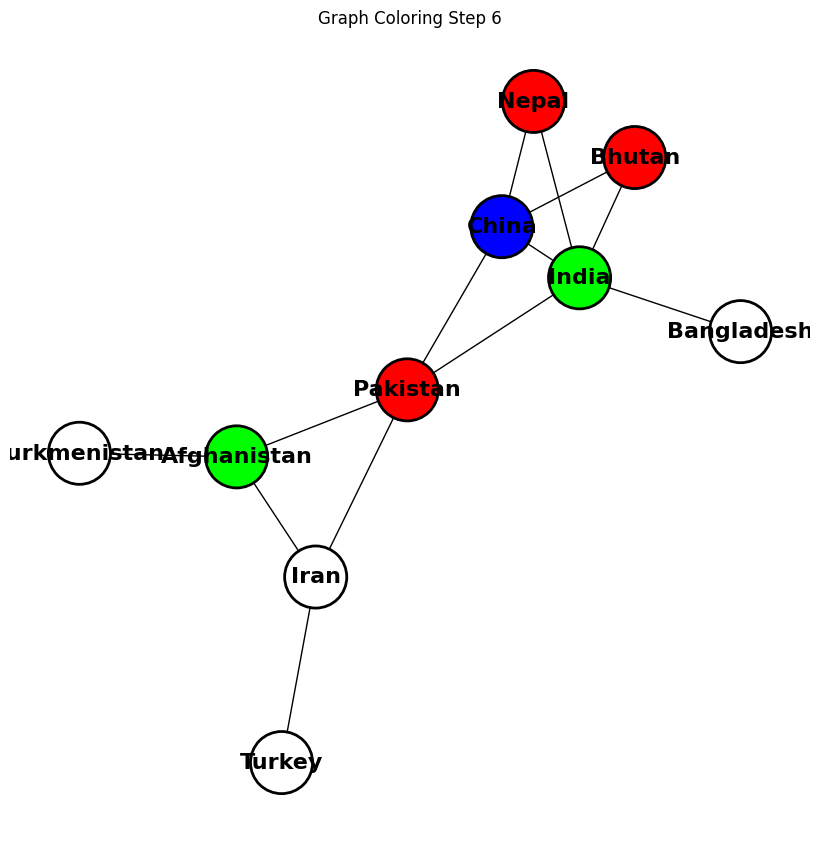

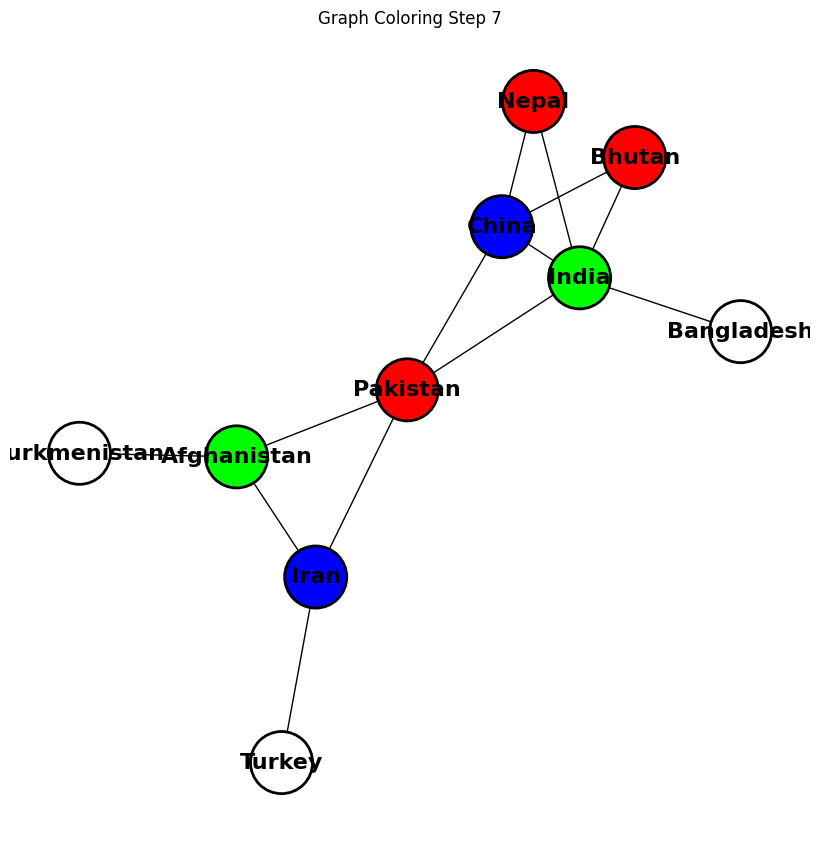

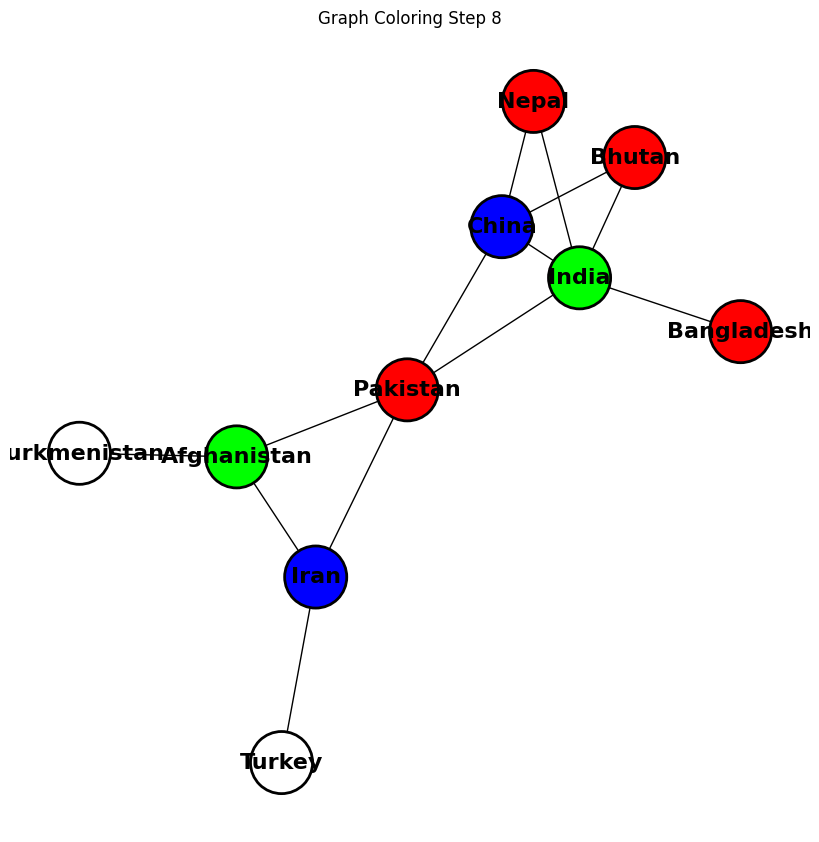

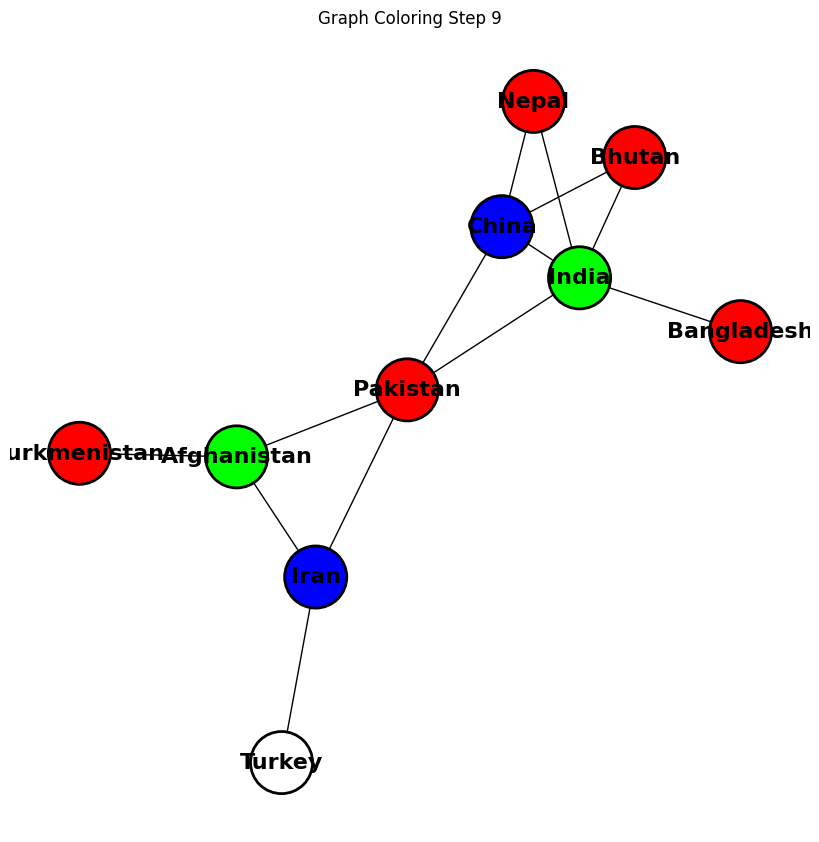

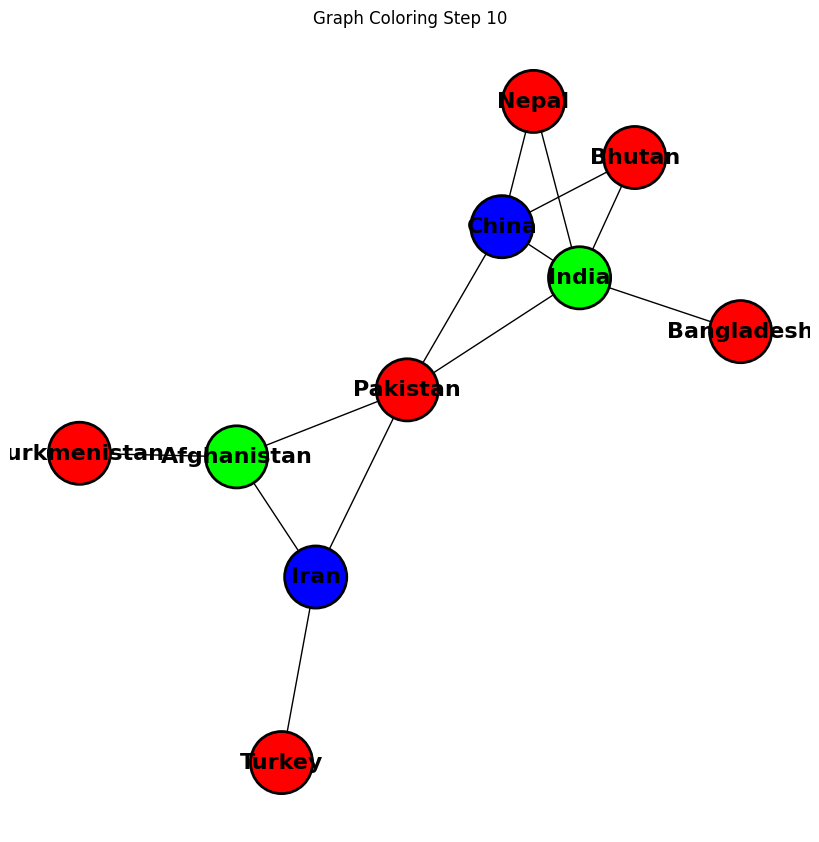

Successfully colored the graph of neighboring countries:
Pakistan: Red
India: Green
China: Blue
Nepal: Red
Bhutan: Red
Afghanistan: Green
Iran: Blue
Bangladesh: Red
Turkmenistan: Red
Turkey: Red


In [1]:
# Install necessary libraries (if needed)
# !pip install networkx matplotlib

import networkx as nx
import matplotlib.pyplot as plt

# Step 1: Define the neighboring countries as a graph
G = nx.Graph()
neighbors = {
    'Pakistan': ['India', 'Afghanistan', 'China', 'Iran'],
    'India': ['Pakistan', 'China', 'Nepal', 'Bhutan', 'Bangladesh'],
    'Afghanistan': ['Pakistan', 'Iran', 'Turkmenistan'],
    'Iran': ['Pakistan', 'Afghanistan', 'Turkey'],
    'China': ['Pakistan', 'India', 'Nepal', 'Bhutan'],
    'Nepal': ['India', 'China'],
    'Bhutan': ['India', 'China'],
    'Bangladesh': ['India'],
    'Turkey': ['Iran'],
    'Turkmenistan': ['Afghanistan']
}

# Convert the dictionary to edges for the graph
for country, borders in neighbors.items():
    for neighbor in borders:
        G.add_edge(country, neighbor)

# Step 2: Define the available colors for countries
colors = ['Red', 'Green', 'Blue']

# Step 3: Visualize the graph coloring step by step
def visualize_graph(assignment, step):
    plt.figure(figsize=(8, 8))  # Increase the figure size for better clarity
    pos = nx.spring_layout(G, seed=42)  # Use spring layout for better node spacing

    # Default color for uncolored nodes is white
    node_colors = ['#ffffff'] * len(G.nodes)

    # Assign colors to the nodes based on the current assignment
    for node, color in assignment.items():
        if color == 'Red':
            node_colors[list(G.nodes).index(node)] = '#FF0000'
        elif color == 'Green':
            node_colors[list(G.nodes).index(node)] = '#00FF00'
        elif color == 'Blue':
            node_colors[list(G.nodes).index(node)] = '#0000FF'

    # Draw the graph with current color assignments
    nx.draw(G, pos, with_labels=True, node_color=node_colors, font_weight='bold',
            node_size=2000, font_size=16, font_color='black', edge_color='black',
            linewidths=2, node_shape='o', edgecolors='black')

    plt.title(f"Graph Coloring Step {step}")
    plt.show()

# Step 4: Function to check if a color assignment is valid
def is_valid_color(node, color, assignment):
    # Check all neighboring nodes to ensure no conflict (no neighbor has the same color)
    for neighbor in G.neighbors(node):
        if neighbor in assignment and assignment[neighbor] == color:
            return False  # Conflict found
    return True  # No conflict

# Step 5: Minimum Remaining Values (MRV) Heuristic
def select_unassigned_node_MRV(assignment):
    unassigned_nodes = [node for node in G.nodes if node not in assignment]
    # For each unassigned node, count the number of legal values (remaining colors)
    mrv_node = None
    min_remaining_values = float('inf')

    for node in unassigned_nodes:
        remaining_values = sum(is_valid_color(node, color, assignment) for color in colors)
        if remaining_values < min_remaining_values:
            min_remaining_values = remaining_values
            mrv_node = node

    return mrv_node

# Step 6: Backtracking algorithm with MRV heuristic
def graph_coloring_MRV(assignment, step):
    # If all nodes are assigned a color, we are done
    if len(assignment) == len(G.nodes):
        return True

    # Select the next node to assign based on MRV heuristic
    node = select_unassigned_node_MRV(assignment)

    # Try assigning each color to the selected node
    for color in colors:
        if is_valid_color(node, color, assignment):
            assignment[node] = color
            visualize_graph(assignment, step)
            # Recurse to the next step
            if graph_coloring_MRV(assignment, step + 1):
                return True
            # If assigning this color leads to no solution, backtrack
            del assignment[node]

    return False

# Step 7: Main function to execute the algorithm
def main():
    assignment = {}
    # Start the graph coloring with MRV
    if graph_coloring_MRV(assignment, 1):
        print("Successfully colored the graph of neighboring countries:")
        for country, color in assignment.items():
            print(f"{country}: {color}")
    else:
        print("No valid coloring possible.")

if __name__ == "__main__":
    main()


**Key Changes:**

**Graph Representation:**

The neighboring countries are represented as a graph using networkx, with each country as a node and borders as edges.
**MRV Heuristic:**
The select_unassigned_node_MRV function selects the uncolored country (node) with the fewest remaining legal colors, minimizing conflicts as the algorithm progresses.

**Visualization:**
The visualize_graph function shows the step-by-step process of coloring the graph. Each country is colored with either 'Red', 'Green', or 'Blue', and uncolored nodes are shown in white.

**Backtracking with MRV:**
The graph_coloring_MRV function applies backtracking, using the MRV heuristic to decide which country to color next. If a conflict arises, the algorithm backtracks and tries a different color.